# Load libraries, data, and define functions

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed
from pathlib import Path
from scipy.stats import norm
from scipy.special import logsumexp
import stan

import nest_asyncio
nest_asyncio.apply()

# load prepared data from data_processing.ipynb
filename = "../Data/gb_energy_data_filled.csv"
data_gb = pd.read_csv(filename)

data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

## Posterior Plotters

In [2]:
def plot_trace_and_densities(fit, param_names, num_samples, n_chains):
    total_param_number = 0
    for param in param_names:
        if param not in fit.keys():
            print(param, "not present.")
            continue
        if fit[param].ndim == 3:
            total_param_number += fit[param].shape[0] * fit[param].shape[1]
        else:
            total_param_number += fit[param].shape[0]

    fig, axes = plt.subplots(total_param_number, 2, figsize=(8, 1.5*total_param_number))
    fig_index = 0
    for param in param_names:
        if fit[param].ndim==3:
            n_row = fit[param].shape[0]
            n_col = fit[param].shape[1]
            for i in range(n_row):
                for j in range(n_col):
                    param_name =  param + "[" + str(i) + ", " + str(j) +"]"
                    posterior_draws = fit[param][i,j].reshape(num_samples, n_chains).T

                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1

        elif fit[param].ndim==2:
            if fit[param].shape[0]>1:
                n_param = fit[param].shape[0]
                for param_index in range(n_param):
                    param_name = param+'[' + str(param_index) +']'
                    posterior_draws = fit[param][param_index].reshape(num_samples, n_chains).T
                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)

                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1
            else:
                posterior_draws = fit[param][0].reshape(num_samples, n_chains).T
                for chain_index in range(n_chains):
                    axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                    axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                axes[fig_index, 0].set_title(param)
                axes[fig_index, 1].set_title(param)
                fig_index += 1
    plt.tight_layout()
    plt.show()


def plot_posterior_scatter_matrix(fit, param_names, num_samples, n_chains, max_points=2000):
    posterior_draws = {}
    for param in param_names:
        if param not in fit.keys():
            print(f"Parameter {param} missing from fit.")
            continue
        arr = fit[param]
        if arr.ndim == 1:
            posterior_draws[param] = arr.reshape(num_samples, n_chains).T.flatten()
        else:
            for k in range(arr.shape[0]):
                posterior_draws[f"{param}[{k+1}]"] = arr[k].reshape(num_samples, n_chains).T.flatten()

    keys = list(posterior_draws.keys())
    if len(keys) == 0:
        return

    total_points = len(next(iter(posterior_draws.values())))
    sample_idx = np.random.choice(total_points, min(total_points, max_points), replace=False)

    n = len(keys)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    for i, xi in enumerate(keys):
        for j, yj in enumerate(keys):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior_draws[xi][sample_idx], bins=30, color='lightblue')
            else:
                ax.scatter(posterior_draws[yj][sample_idx],
                           posterior_draws[xi][sample_idx],
                           s=3, alpha=0.4)
            if i == n - 1:
                ax.set_xlabel(yj)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(xi)
            else:
                ax.set_yticklabels([])

    fig.suptitle("Posterior draw scatter matrix")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Posterior Predictive Sampling Functions

In [3]:
def mean_function(parameter_values, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(parameter_values.shape[0]) if 'day_coef' in parameter_values.keys()[i]]
    hour_coef_index = [i for i in range(parameter_values.shape[0]) if 'hour_coef' in parameter_values.keys()[i]]

    day_coef_vals = np.insert(parameter_values.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(parameter_values.iloc[hour_coef_index].to_numpy(), 0 , 0.0)

    # f_1
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']]
    # f_2
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] + parameter_values['fourier_coef.1'] * np.cos(2*np.pi*X_data['time_year']) + parameter_values['fourier_coef.2'] * np.sin(2*np.pi*X_data['time_year'])
    # f_3
    mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] 
    for k in range(1,4):
        a1 = parameter_values['fourier_coef.1.' + str(k)]
        a2 = parameter_values['fourier_coef.2.' + str(k)]
        mean += a1* np.cos(2*np.pi*k*X_data['time_year']) + a2 * np.sin(2*np.pi*k*X_data['time_year'])
    return mean.to_numpy()

def posterior_det_mean(post_df: pd.DataFrame, X_data: pd.DataFrame):    
    n_post = post_df.shape[0]
    n_data = X_data.shape[0]
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        output[post_ind, :] = mean_function(post_df.iloc[post_ind,:], X_data)
    return output

def one_step_prediction(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = len(y_data)

    log_p_jump = np.log(post['p_jump'].iloc[0])
    log_p_nojump = np.log(1.0 - post['p_jump'].iloc[0])

    one_step_pred = np.empty((n_post, n_data))
    one_step_expectation = np.empty((n_post, n_data))

    ou_sd_arr = np.empty((n_post, 2))
    ou_sd_arr[:,0] = post.loc[:, 'sigma.1'] * np.sqrt( (1-post.loc[:,'alpha.1']**2) / (2*post.loc[:,'theta.1']))
    ou_sd_arr[:,1] = post.loc[:, 'sigma.2'] * np.sqrt( (1-post.loc[:,'alpha.2']**2) / (2*post.loc[:,'theta.2']))
    ou_var_arr = ou_sd_arr * ou_sd_arr
    jump_sd_arr = np.sqrt( ou_var_arr[:,0] + post.loc[:,'sigma_jump']**2)
    jump_var_arr = jump_sd_arr**2

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        pred = np.empty(n_data)
        expectation = np.empty(n_data)

        # -- calculate deterministic mean
        det_mean = mean_function(param_vals, X_data)

        # -- recurring elements
        log_predict_prob = np.empty(2)
        predict_prob = np.empty(2)
        log_filtered_prob = np.empty(2)
        log_emit = np.empty((n_data-1, 2))
        log_component_density = np.empty(2)

        m1 = det_mean[1:] + param_vals['alpha.1'] * (y_data[:-1] - det_mean[:-1])
        m2 = det_mean[1:] + param_vals['alpha.2'] * (y_data[:-1] - det_mean[:-1])

        log_jump_density = log_p_jump + norm.logpdf(y_data[1:], loc = m1 + param_vals['mu_jump'], scale=jump_sd_arr[post_ind])
        log_nojump_density = log_p_nojump + norm.logpdf(y_data[1:], loc=m1, scale=ou_sd_arr[post_ind, 0])

        log_emit[:,0] = np.log( np.exp(log_jump_density) + np.exp(log_nojump_density))
        log_emit[:,1] = norm.logpdf(y_data[1:], loc = m2, scale=ou_sd_arr[post_ind, 1])

        # -- condition on the first observation
        pred[0] = y_data[0]
        expectation[0] = y_data[0]

        log_filtered_prob[0] = np.log(param_vals['pi.1'])
        log_filtered_prob[1] = np.log(param_vals['pi.2'])

        log_A = np.empty((2,2))
        log_A[0,0] = np.log(param_vals['A.1.1'])
        log_A[0,1] = np.log(param_vals['A.1.2'])
        log_A[1,0] = np.log(param_vals['A.2.1'])
        log_A[1,1] = np.log(param_vals['A.2.2'])

        for data_ind in range(1, n_data):
            predict_prob[0] = np.exp(log_A[0,0] + log_filtered_prob[0]) + np.exp(log_A[0,1] + log_filtered_prob[1]) 
            predict_prob[1] = np.exp(log_A[1,0] + log_filtered_prob[0]) + np.exp(log_A[1,1] + log_filtered_prob[1]) 
            log_predict_prob = np.log(predict_prob)

            # -- draw next value and calc expectation --
            m = np.empty(2)
            m[0] = det_mean[data_ind] + param_vals['alpha.1'] * (y_data[data_ind-1] - det_mean[data_ind-1])
            m[1] = det_mean[data_ind] + param_vals['alpha.2'] * (y_data[data_ind-1] - det_mean[data_ind-1])

            expectation[data_ind] = predict_prob[0]*(m[0] + param_vals['p_jump'] * param_vals['mu_jump']) + predict_prob[1]*m[1]

            if (np.random.binomial(1, predict_prob[0])):
                jump_draw = np.random.binomial(1, param_vals['p_jump'])
                pred[data_ind] = m[0] + jump_draw * param_vals['mu_jump'] + np.sqrt(ou_var_arr[post_ind, 0] + jump_draw * jump_var_arr[post_ind])  * np.random.normal()
            else:
                pred[data_ind] = m[1] + ou_sd_arr[post_ind, 1] * np.random.normal()
        
            # -- log-likelihood
            log_component_density[0] = log_predict_prob[0] + log_emit[data_ind-1, 0]
            log_component_density[1] = log_predict_prob[1] + log_emit[data_ind-1, 1]

            # -- latent probabilities, alpha_t
            log_normalising_const = np.log( sum(np.exp(log_component_density)) )
            log_filtered_prob[0] = log_predict_prob[0] + log_emit[data_ind-1, 0] - log_normalising_const
            log_filtered_prob[1] = log_predict_prob[1] + log_emit[data_ind-1, 1] - log_normalising_const
        
        one_step_pred[post_ind, :] = pred
        one_step_expectation[post_ind, :] = expectation

    return one_step_expectation, one_step_pred

def forward_algorithm_loglik(param_vals: pd.Series, y_data: np.array, X_data: pd.DataFrame, mean: np.array):
    if mean.shape[1] != 2:
        raise ValueError("'mean' must have two columns.")
    
    n_data = y_data.shape[0]

    log_p_jump = np.log(param_vals['p_jump'])
    log_p_nojump = np.log(1.0 - param_vals['p_jump'])

    log_lik = np.empty(n_data-1)

    ou_sd_arr = np.empty(2)
    ou_sd_arr[0] = param_vals['sigma.1'] * np.sqrt( (1-param_vals['alpha.1']**2) / (2*param_vals['theta.1']))
    ou_sd_arr[1] = param_vals['sigma.2'] * np.sqrt( (1-param_vals['alpha.2']**2) / (2*param_vals['theta.2']))

    jump_sd_arr = np.sqrt(ou_sd_arr[0]**2 + param_vals['sigma_jump']**2)

    # -- recurring elements
    log_emit = np.empty((n_data-1, 2))
    log_predict_prob = np.empty(2)
    predict_prob = np.empty(2)
    log_filtered_prob = np.empty(2)
    log_component_density = np.empty(2)

    log_jump_density = log_p_jump + norm.logpdf(y_data[1:], loc=mean[:,0] + param_vals['mu_jump'], scale=jump_sd_arr)
    log_nojump_density = log_p_nojump + norm.logpdf(y_data[1:], loc=mean[:,1], scale=ou_sd_arr[0])

    log_emit[:,0] = np.log( np.exp(log_jump_density) + np.exp(log_nojump_density))
    log_emit[:,1] = norm.logpdf(y_data[1:], loc=mean[:,1], scale=ou_sd_arr[1])

    # -- condition on the first observation
    log_filtered_prob[0] = np.log(param_vals['pi.1'])
    log_filtered_prob[1] = np.log(param_vals['pi.2'])

    log_A = np.empty((2,2))
    log_A[0,0] = np.log(param_vals['A.1.1'])
    log_A[0,1] = np.log(param_vals['A.1.2'])
    log_A[1,0] = np.log(param_vals['A.2.1'])
    log_A[1,1] = np.log(param_vals['A.2.2'])

    for data_ind in range(1, n_data):
        predict_prob[0] = np.exp(log_A[0,0] + log_filtered_prob[0]) + np.exp(log_A[0,1] + log_filtered_prob[1]) 
        predict_prob[1] = np.exp(log_A[1,0] + log_filtered_prob[0]) + np.exp(log_A[1,1] + log_filtered_prob[1]) 
        log_predict_prob = np.log(predict_prob)

        # -- log-likelihood
        log_component_density[0] = log_predict_prob[0] + log_emit[data_ind-1, 0]
        log_component_density[1] = log_predict_prob[1] + log_emit[data_ind-1, 1]

        # -- latent probabilities, alpha_t
        log_normalising_const = logsumexp(log_component_density)
        log_filtered_prob[0] = log_predict_prob[0] + log_emit[data_ind-1, 0] - log_normalising_const
        log_filtered_prob[1] = log_predict_prob[1] + log_emit[data_ind-1, 1] - log_normalising_const

        log_lik[data_ind-1] = log_normalising_const
        
    return log_lik

def posterior_loglik(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame, predicitve=False):
    n_post = post.shape[0]
    n_data = X_data.shape[0]

    loglik = np.empty((n_post, n_data-1))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        det_mean = mean_function(param_vals, X_data)

        mean = np.empty((n_data-1, 2))
        if predicitve: 
            latent_state, pred_sample = sample_process(param_vals, y_data[0], X_data)
            mean[:,0] = det_mean[1:] + param_vals['alpha.1'] * (pred_sample[:-1] - det_mean[:-1])
            mean[:,1] = det_mean[1:] + param_vals['alpha.2'] * (pred_sample[:-1] - det_mean[:-1])
        else:
            mean[:,0] = det_mean[1:] + param_vals['alpha.1'] * (y_data[:-1] - det_mean[:-1])
            mean[:,1] = det_mean[1:] + param_vals['alpha.2'] * (y_data[:-1] - det_mean[:-1])

        loglik[post_ind,:] = forward_algorithm_loglik(param_vals, y_data, X_data, mean)

    return loglik


def sample_process(param_vals: pd.Series, y_initial_value: float, X_data: pd.DataFrame):
    n_step = X_data.shape[0]

    sample = np.empty(n_step)
    regime = np.empty(n_step)

    sample[0] = y_initial_value

    ou_sd = np.empty(2)
    ou_sd[0] = param_vals['sigma.1'] * np.sqrt( (1-param_vals['alpha.1']**2) / (2*param_vals['theta.1']))
    ou_sd[1] = param_vals['sigma.2'] * np.sqrt( (1-param_vals['alpha.2']**2) / (2*param_vals['theta.2']))
    ou_var = ou_sd * ou_sd
    jump_sd = np.sqrt(ou_var[0] + param_vals['sigma_jump']**2)
    jump_var = jump_sd**2

    det_mean = mean_function(param_vals, X_data)

    # -- Draw first sample based on initial distribution pi
    regime[0] = np.random.choice([1.0, 2.0], p=[param_vals['pi.1'], param_vals['pi.2']])
                                            
    if regime[0] == 0:
        jump_ind = np.random.binomial(1, param_vals['p_jump'])
        m = det_mean[1] + param_vals['alpha.1'] * (sample[0] - det_mean[0]) + jump_ind * param_vals['mu_jump']
        sample[1] = m + np.sqrt(ou_var[0] + jump_ind * jump_var) * np.random.normal()
    else:
        m = det_mean[1] + param_vals['alpha.2'] * (sample[0] - det_mean[0]) 
        sample[1] = m + ou_sd[1] * np.random.normal()

    # -- Draw following samples using transition matrix A
    for step_ind in range(1, n_step):
        if regime[step_ind-1]==1:
            regime[step_ind] = np.random.choice([1.0,2.0], p=[param_vals['A.1.1'], param_vals['A.1.2']])
        else:
                regime[step_ind] = np.random.choice([1.0,2.0], p=[param_vals['A.2.1'], param_vals['A.2.2']])

        if regime[step_ind]==1:
            jump_ind = np.random.binomial(1, p=param_vals['p_jump'])
            m = det_mean[step_ind] + param_vals['alpha.1'] * (sample[step_ind-1] - det_mean[step_ind-1]) + jump_ind * param_vals['mu_jump']
            sample[step_ind] = m + np.sqrt(ou_var[0] + jump_ind * jump_var) * np.random.normal()
        else:
            m = det_mean[step_ind] + param_vals['alpha.2'] * (sample[step_ind-1] - det_mean[step_ind-1]) 
            sample[step_ind] = m + ou_sd[1] * np.random.normal()

    return regime, sample
    

def predictive_sample(post: pd.DataFrame, y_initial_value: float, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_step = X_data.shape[0]

    forecast = np.empty((n_post, n_step))
    latent_state = np.empty((n_post, n_step))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        reg, samp = sample_process(param_vals, y_initial_value, X_data)
        
        forecast[post_ind,:] = samp
        latent_state[post_ind, :] = reg

    return latent_state, forecast

In [4]:
training_window_size = 2*365 

final_month = data_gb.index.max().to_period("M")
validation_data = data_gb[data_gb.index.to_period("M") == final_month]
validation_data_start_date = min(validation_data.index)
validation_data_end_date = max(validation_data.index)
validation_data_days = np.unique(validation_data.index.to_period("D"))

training_window_start_date = validation_data_start_date - pd.Timedelta(days=training_window_size)
training_data = data_gb[(data_gb.index>=training_window_start_date) &
                        (data_gb.index<validation_data_start_date)]

print("Validation data time limits: " + str(validation_data_start_date) + ", " + str(validation_data_end_date))

Validation data time limits: 2020-09-01 00:00:00+00:00, 2020-09-30 23:00:00+00:00


/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_18765/3974001527.py:3: UserWarning: Converting to Period representation will drop timezone information.
  final_month = data_gb.index.max().to_period("M")
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_18765/3974001527.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data = data_gb[data_gb.index.to_period("M") == final_month]
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_18765/3974001527.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data_days = np.unique(validation_data.index.to_period("D"))


In [5]:
# Stan is 1-indexed, so add 1
day_idx   = (training_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx  = (training_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

day_idx_fore = (validation_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx_fore = (validation_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0], training_data.shape[0] + validation_data.shape[0]) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

# Fit model

## Run Inference

In [10]:
filename = "./Posterior/oujp_parameters.csv"
oujp_post = pd.read_csv(filename)

In [11]:
stan_data = {
    # -- TRAINING DATA -------------------
    'T': len(training_data['price_day_ahead_filled']),
    'y': training_data['price_day_ahead_filled'].to_numpy(),
    'time_year': training_X_data['time_year'].to_numpy(),
    'day_of_week_index': training_X_data['day_indicator'].to_numpy(),
    'hour_index': training_X_data['hour_indicator'].to_numpy(),
    'dt': 1,

    # -- VALIDATION DATA -----------------
    'T_fore': validation_data.shape[0], 
    'day_of_week_index_fore': validation_X_data['day_indicator'].to_numpy(),
    'hour_index_fore': validation_X_data['hour_indicator'].to_numpy(),

    # -- BASE REGIME ----------------------
    # ---- reversion strength
    'theta_base_mu': 2,
    'theta_base_sd': 1,
    # ---- volatility
    'sigma_base_shape': 3 ** 2 / 1,
    'sigma_base_rate': 3 / 1,

    # -- SPIKE REGIME ---------------------
    # ---- reversion rate
    'theta_spike_mu': 5, 
    'theta_spike_sd': 1,
    # ---- spike regime volatility 
    'sigma_spike_shape': 8 ** 2 / 2, 
    'sigma_spike_rate': 8 / 2,

    # -- JUMP PROCESS ----------------------
    # ---- probability of a jump
    # 'p_jump_alpha': 1, 
    # 'p_jump_beta': 50,
    # ---- expected jump size
    'mu_jump_mean': 0, 
    'mu_jump_sd': 1,
    # ---- jump variance
    'sigma_jump_shape': 50 ** 2 / 5, 
    'sigma_jump_rate': 50 / 5,

    # -- HMM -------------------------------
    # ---- Transition
    'A_weights': [[99,  1],
                  [90, 10]],
    # ---- Initial state
    'pi_weights': [99,1],
    
    # -- MEAN FUNCTION ---------------------
    'overall_mean_mu': np.mean(training_data['GB_GBN_price_day_ahead']),
    'overall_mean_sd': 5,
    'yearly_trend_mu': 0, 
    'yearly_trend_sd': 10,

    # -- fixing parameters ----
    'p_jump': np.mean(oujp_post['p_jump'])
}

In [ ]:
stan_model_file = Path('./stan_files/mrs_oujp_ou.stan')
model_code = stan_model_file.read_text()
posterior = stan.build(model_code, data=stan_data)

n_chains = 4
n_burnin = 500
n_posterior = 1000

fit = posterior.sample(num_chains=n_chains, num_samples=n_posterior, num_warmup=n_burnin)

Building...

In file included from /Users/b6072271/Library/Caches/httpstan/4.13.0/models/ko5ia7k3/model_ko5ia7k3.cpp:2:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/model/model_header.hpp:4:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math.hpp:19:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math/rev.hpp:4:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/stan/math/prim/fun/Eigen.hpp:23:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/Eigen/Sparse:26:
In file included from /Users/b6072271/Documents/Job Projects/Energy Prices/.venv/lib/python3.13/site-packages/httpstan/include/Eigen/Spars

5 warnings generated.

Building: 16.4s, done.Messages from stanc:
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    is provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (1/6000)
Sampling:   0%

## Plot posterior chains

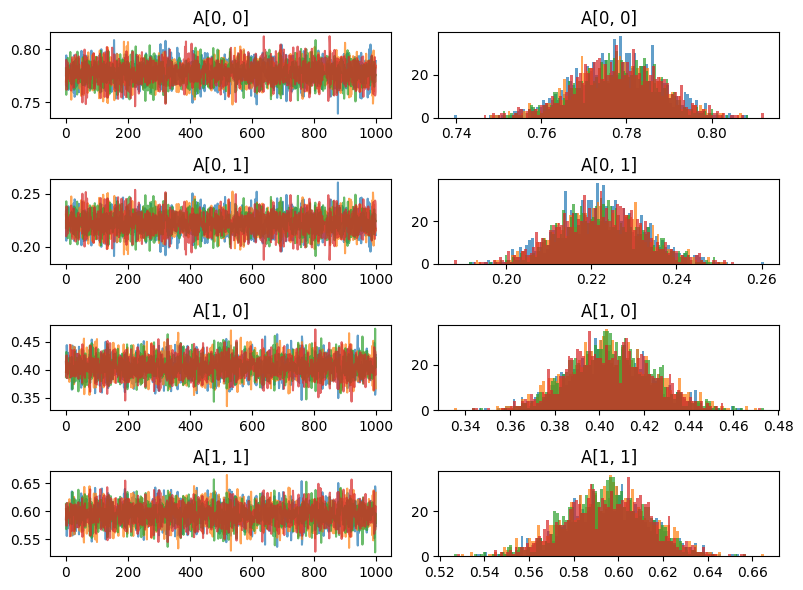

In [91]:
plot_trace_and_densities(fit, ['A'], n_posterior, n_chains)

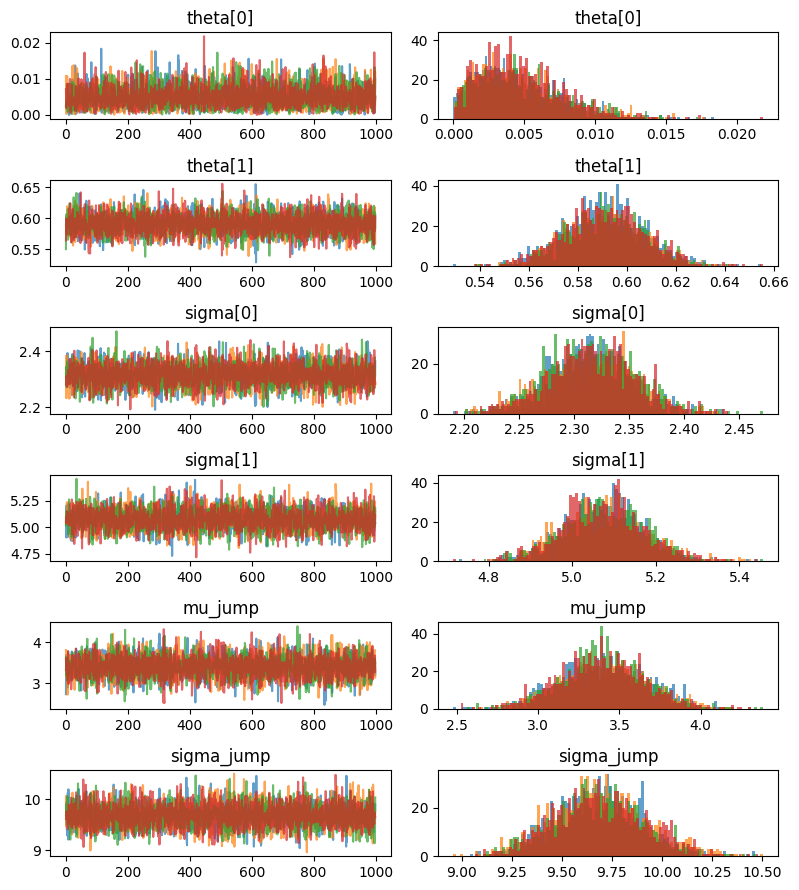

In [92]:
plot_trace_and_densities(fit, ['theta', 'sigma', 'mu_jump', 'sigma_jump'], n_posterior, n_chains)

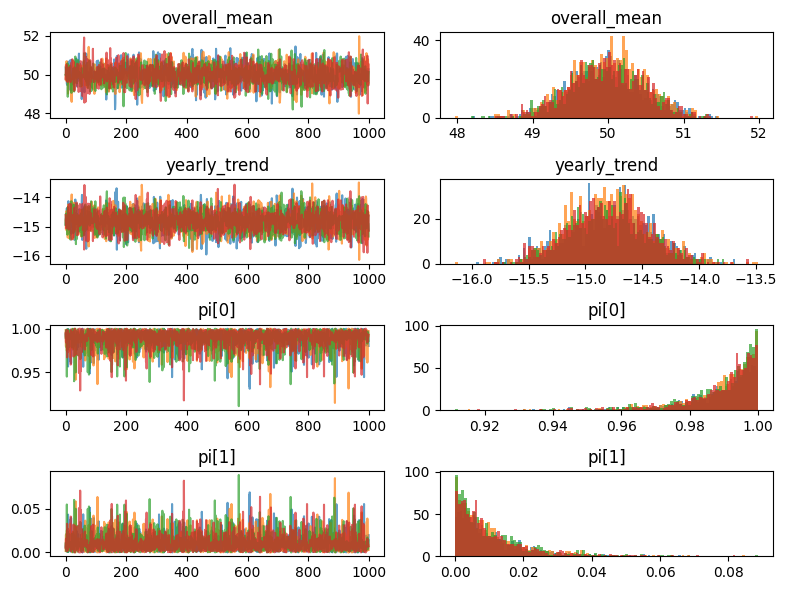

In [93]:
plot_trace_and_densities(fit, ['overall_mean', 'yearly_trend', 'pi'], n_posterior, n_chains)

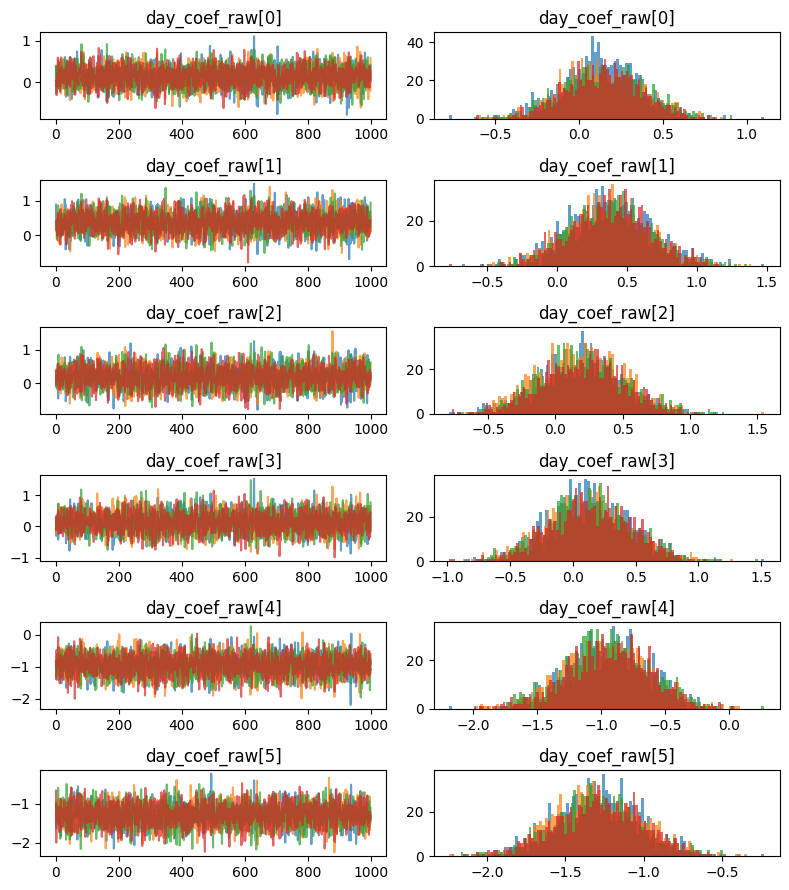

In [94]:
plot_trace_and_densities(fit, ['day_coef_raw'], n_posterior, n_chains)

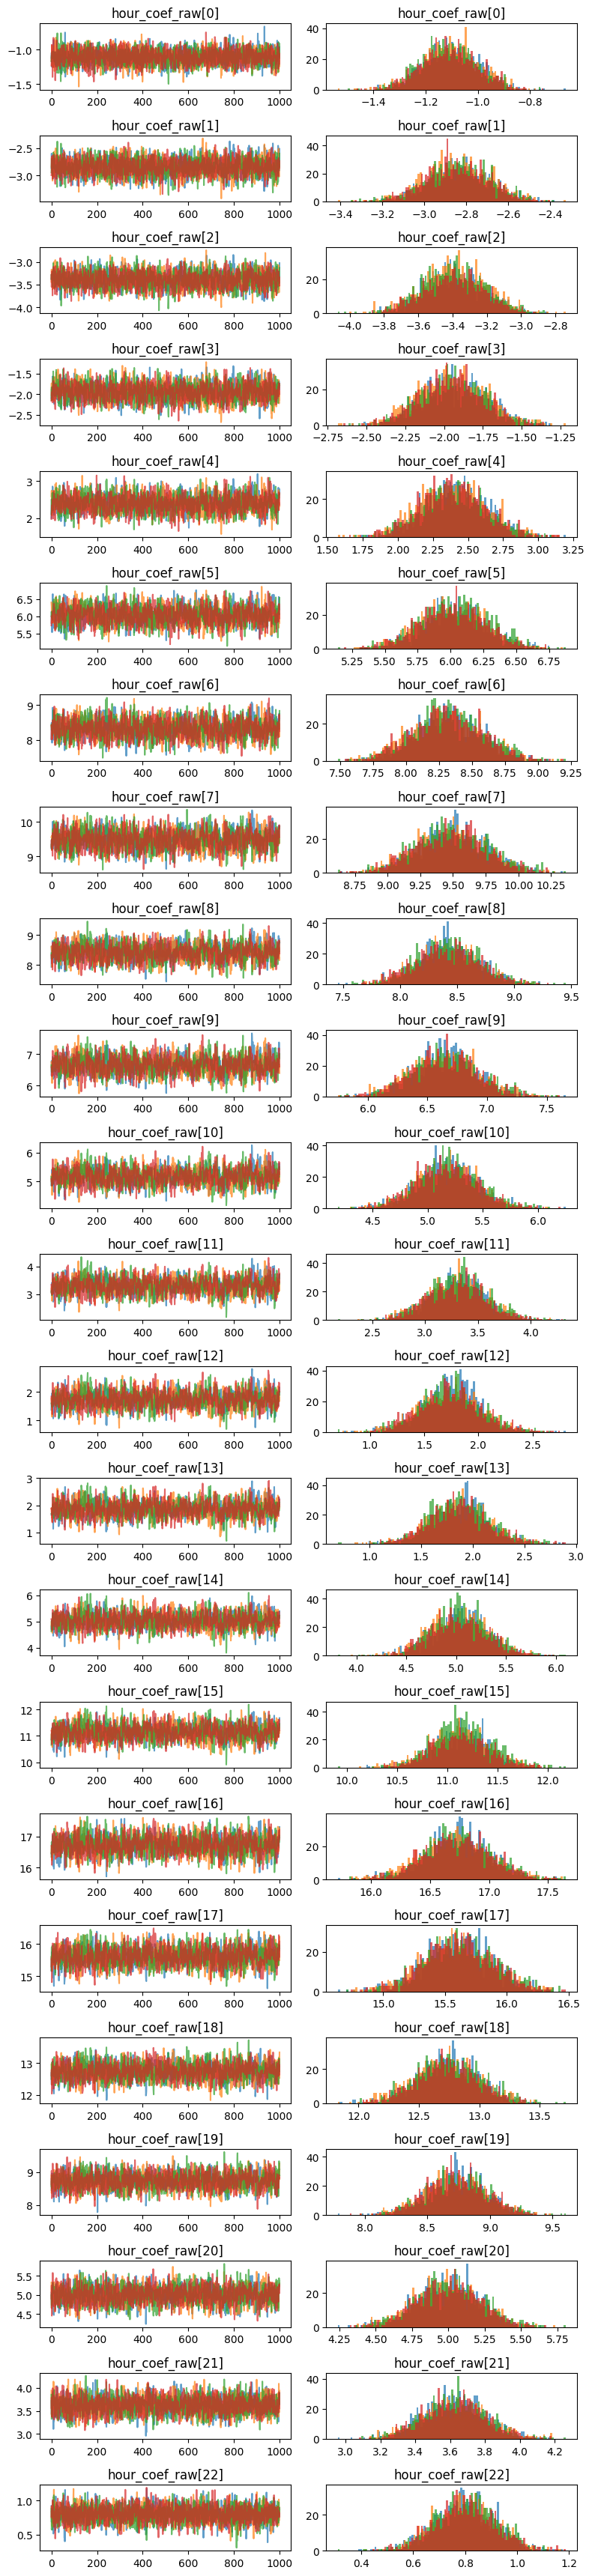

In [95]:
plot_trace_and_densities(fit, ['hour_coef_raw'], n_posterior, n_chains)

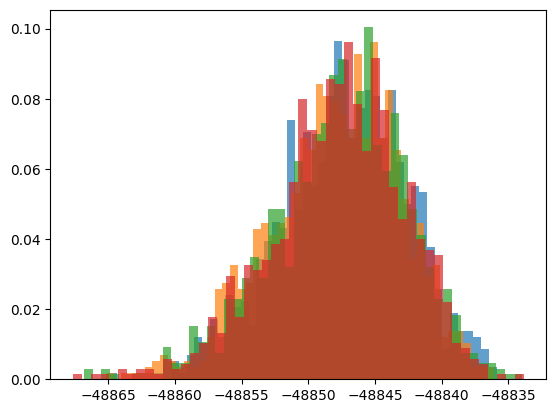

In [96]:
loglik = fit['lp__'].reshape(n_posterior, n_chains).T
for ind in range(n_chains):
    plt.hist(loglik[ind], 50, density=True,
            alpha=0.7);

## Save Posterior file

In [ ]:
# Save the posterior parameter draws
save_output = False

if save_output:
    fit_df = fit.to_frame()
    fit_df['p_jump'] = stan_data['p_jump']

    param_names = ['lp__', 'overall_mean', 'yearly_trend', 'mu_jump', 'sigma_jump', 'p_jump']
    for i in range(1,7):
        param_names.append("day_coef_raw." + str(i))
    for i in range(1,24):
        param_names.append("hour_coef_raw." + str(i))
    for i in range(1,3):
        param_names.append("pi." + str(i))
        param_names.append("theta." + str(i))
        param_names.append("sigma." + str(i))
        param_names.append("alpha." + str(i))
    for i in range(1,3):
        for j in range(1,3):
            param_names.append("A." + str(i) + "." + str(j))
    for i in range(1,3):
        for j in range(1,4):
            param_names.append("fourier_coef." + str(i) + "." + str(j))
        
    print(param_names)
    post_to_save = fit_df[param_names]
    post_to_save.to_csv("./Posterior/mrs_oujp_ou_fix_pjump_parameters.csv")


['lp__', 'overall_mean', 'yearly_trend', 'mu_jump', 'sigma_jump', 'p_jump', 'day_coef_raw.1', 'day_coef_raw.2', 'day_coef_raw.3', 'day_coef_raw.4', 'day_coef_raw.5', 'day_coef_raw.6', 'hour_coef_raw.1', 'hour_coef_raw.2', 'hour_coef_raw.3', 'hour_coef_raw.4', 'hour_coef_raw.5', 'hour_coef_raw.6', 'hour_coef_raw.7', 'hour_coef_raw.8', 'hour_coef_raw.9', 'hour_coef_raw.10', 'hour_coef_raw.11', 'hour_coef_raw.12', 'hour_coef_raw.13', 'hour_coef_raw.14', 'hour_coef_raw.15', 'hour_coef_raw.16', 'hour_coef_raw.17', 'hour_coef_raw.18', 'hour_coef_raw.19', 'hour_coef_raw.20', 'hour_coef_raw.21', 'hour_coef_raw.22', 'hour_coef_raw.23', 'pi.1', 'theta.1', 'sigma.1', 'alpha.1', 'pi.2', 'theta.2', 'sigma.2', 'alpha.2', 'A.1.1', 'A.1.2', 'A.2.1', 'A.2.2', 'fourier_coef.1.1', 'fourier_coef.1.2', 'fourier_coef.1.3', 'fourier_coef.2.1', 'fourier_coef.2.2', 'fourier_coef.2.3']


# Posterior Predictive Samples 

In [14]:
# Include the final observation of the training data in the validation data, so that it can be conditioned upon
day_idx   = (training_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx  = (training_data.index.hour ).to_numpy(dtype=int)   # 0-23

day_idx_fore = (validation_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx_fore = (validation_data.index.hour).to_numpy(dtype=int)   # 0-23

day_idx_fore = np.insert(day_idx_fore, 0, day_idx[-1])
hour_idx_fore = np.insert(hour_idx_fore, 0, hour_idx[-1])


time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0]-1, training_data.shape[0] + validation_data.shape[0]) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time': pd.date_range(training_data.index[-1], validation_data.index[-1], freq="h"),
    'price_day_ahead_filled': np.insert(validation_data['price_day_ahead_filled'].to_numpy(), 0, training_data['price_day_ahead_filled'].iloc[-1]),
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

filename = "./Posterior/mrs_oujp_ou_fix_pjump_parameters.csv"
post_df = pd.read_csv(filename)
post_df['p_jump'] = oujp_post['p_jump']

In [15]:
one_step_expected, one_step_pred = one_step_prediction(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)

In [16]:
latent_sample, pred_sample = predictive_sample(post_df, training_data['price_day_ahead_filled'].iloc[0], training_X_data)

KeyboardInterrupt: 

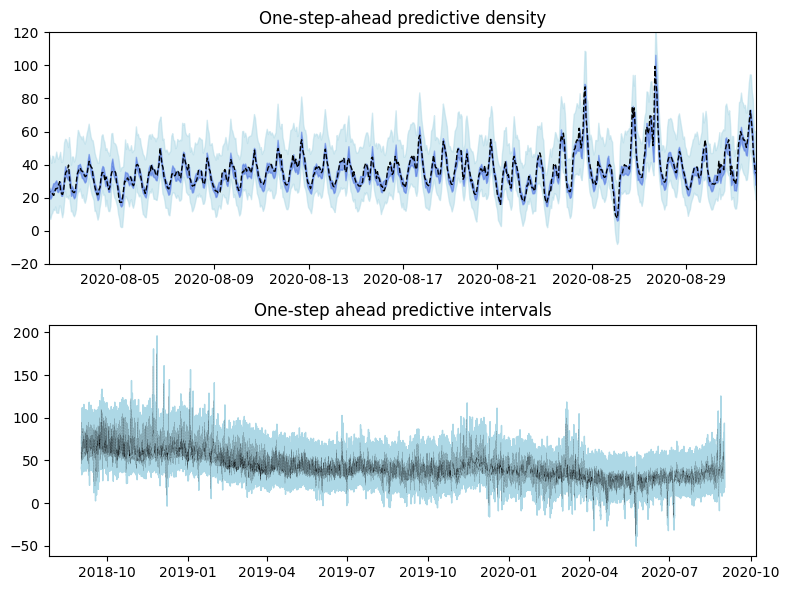

In [74]:
one_step_pred_qnts = np.quantile(one_step_pred, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=0.5, color='lightblue')
axes[0].fill_between(training_data.index, 
                one_step_pred_qnts[1], 
                one_step_pred_qnts[2], 
                alpha=0.5, color='royalblue')
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[0].set_xlim([training_data.index[-30*24], training_data.index[-1]])
axes[0].set_ylim([-20,120])
axes[0].set_title("One-step-ahead predictive density")

axes[1].fill_between(training_data.index, 
                one_step_pred_qnts[0], 
                one_step_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("One-step ahead predictive intervals")

plt.tight_layout()
plt.show()

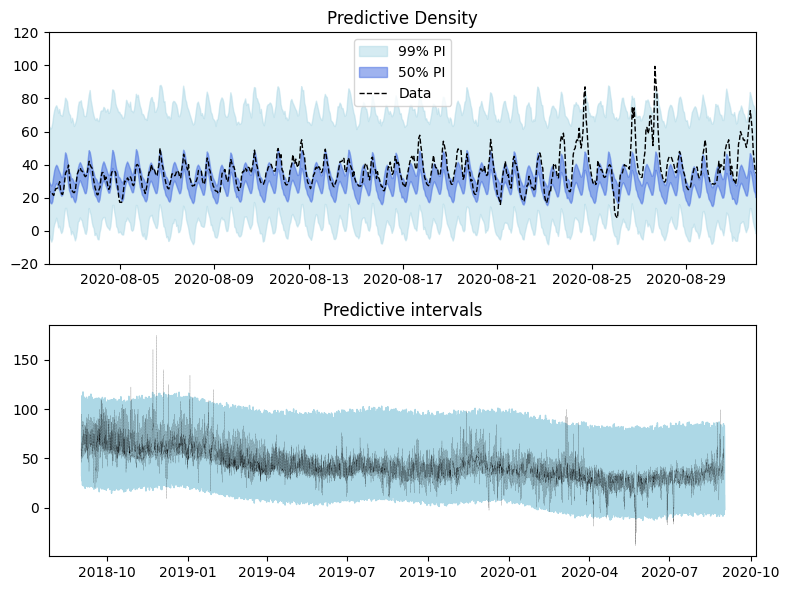

In [77]:
post_pred_qnts = np.quantile(pred_sample, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[0].fill_between(training_data.index, 
                post_pred_qnts[1], 
                post_pred_qnts[2], 
                alpha=0.5, color='royalblue', label="50% PI")
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[0].set_xlim([training_data.index[-30*24], training_data.index[-1]])
axes[0].set_ylim([-20,120])
axes[0].set_title("Predictive Density")
axes[0].legend()

axes[1].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("Predictive intervals")

plt.tight_layout()
plt.show()

In [78]:
quantile_diff = post_pred_qnts[3] - post_pred_qnts[0]
print("Mean width of 99% PI:", np.mean(quantile_diff))

Mean width of 99% PI: 69.60992985500842


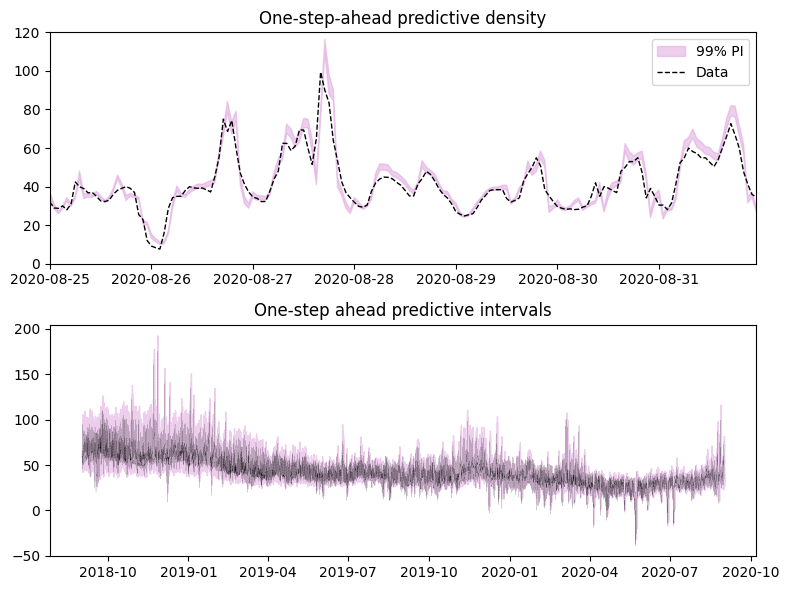

In [82]:
expected_qnts = np.quantile(one_step_expected, [0.005, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                expected_qnts[0], 
                expected_qnts[1], 
                alpha=0.5, color='plum', label="99% PI")
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[0].set_xlim([training_data.index[-7*24], training_data.index[-1]])
axes[0].set_ylim([0, 120])
axes[0].set_title("One-step-ahead predictive density")
axes[0].legend()

axes[1].fill_between(training_data.index, 
                expected_qnts[0], 
                expected_qnts[1], 
                alpha=0.5, color='plum')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("One-step ahead predictive intervals")

plt.tight_layout()
plt.show()

In [83]:
quantile_diff = expected_qnts[1] - expected_qnts[0]
print("Mean width of 99% PI:", np.mean(quantile_diff))

Mean width of 99% PI: 2.5508400329288


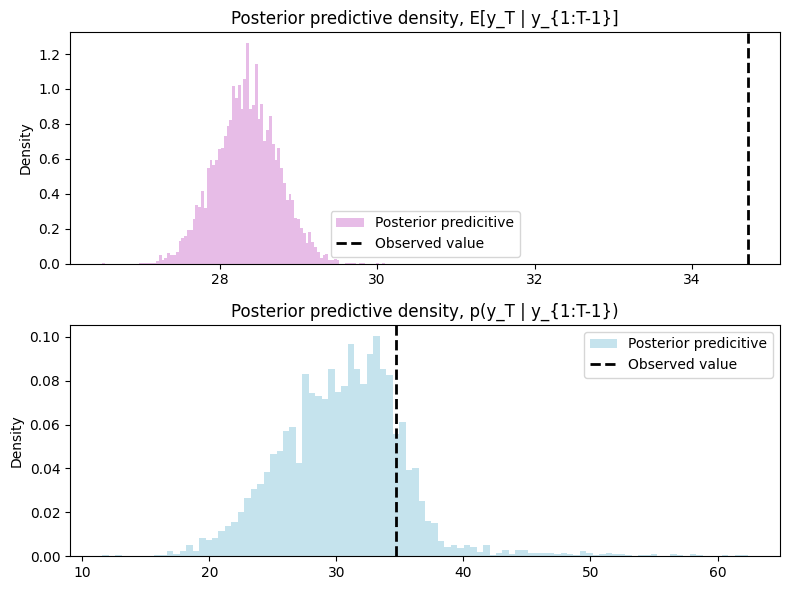

In [86]:
fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].hist(one_step_expected[:,-1], 100, density=True,
         color='plum', alpha=0.7, label="Posterior predicitive")
axes[0].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
axes[0].set_ylabel("Density")
axes[0].set_title("Posterior predictive density, E[y_T | y_{1:T-1}]")
# axes[0].set_xlim(min(y_expected_df.iloc[:,-1]), max(y_expected_df.iloc[:,-1]))
axes[0].legend()

axes[1].hist(one_step_pred[:,-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="Posterior predicitive");
axes[1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="Observed value")
axes[1].set_ylabel("Density")
axes[1].set_title("Posterior predictive density, p(y_T | y_{1:T-1})")
axes[1].legend()

plt.tight_layout()


In [41]:
latent_sample_fore, pred_sample_fore = predictive_sample(post_df, validation_data['price_day_ahead_filled'].iloc[0], validation_X_data)

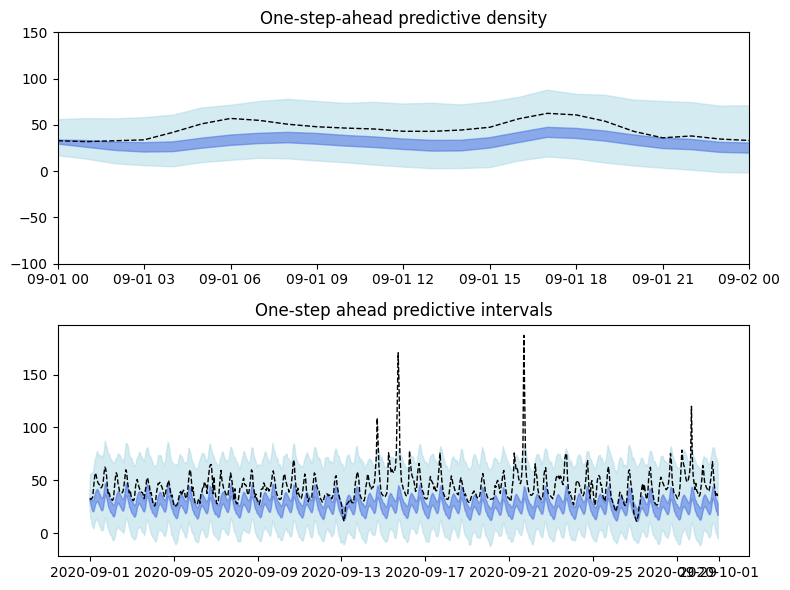

In [ ]:
pred_sample_fore_qnts = np.quantile(pred_sample_fore, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[0], 
                pred_sample_fore_qnts[3], 
                alpha=0.5, color='lightblue')
axes[0].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[1], 
                pred_sample_fore_qnts[2], 
                alpha=0.5, color='royalblue')
axes[0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[0].set_xlim([validation_data.index[0], validation_data.index[24]])
axes[0].set_ylim([-100,150])
axes[0].set_title("Pedictive intervals - validation data")

axes[1].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[0], 
                pred_sample_fore_qnts[3], 
                alpha=0.5, color='lightblue')
axes[1].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[1], 
                pred_sample_fore_qnts[2], 
                alpha=0.5, color='royalblue')
axes[1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[1].set_title("Predictive intervals - validation data")

plt.tight_layout()
plt.show()

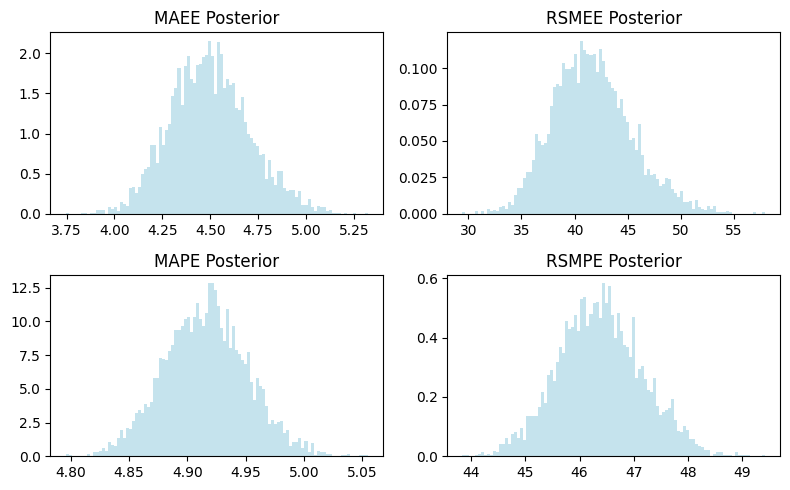

In [90]:
posterior_y_expected = one_step_expected
posterior_y_pred = one_step_pred

n_post = one_step_expected.shape[0]
posterior_maee = np.empty(n_post)
posterior_rmsee = np.empty(n_post)
posterior_mape = np.empty(n_post)
posterior_rmspe = np.empty(n_post)

for ind in range(n_post):
    maee = np.mean(abs(one_step_expected[ind, :] - training_data['GB_GBN_price_day_ahead']))
    posterior_maee[ind] = maee
    rmsee = np.mean( (one_step_expected[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmsee[ind] = rmsee

for ind in range(n_post):
    mape = np.mean(abs(one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead']))
    posterior_mape[ind] = mape
    rmspe = np.mean( (one_step_pred[ind, :] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmspe[ind] = rmspe

fig, axes = plt.subplots(2,2, figsize=(8, 5))

axes[0,0].hist(posterior_maee, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,0].set_title("MAEE Posterior")
axes[0,1].hist(posterior_rmsee, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,1].set_title("RSMEE Posterior")

axes[1,0].hist(posterior_mape, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,0].set_title("MAPE Posterior")
axes[1,1].hist(posterior_rmspe, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,1].set_title("RSMPE Posterior")

plt.tight_layout()
plt.show()

# Model fit and Predictive Statistics

In [53]:
def log_predictive_score_from_loglik(loglik_mat: np.array):
    n_post = loglik_mat.shape[0]

    return logsumexp(loglik_mat, axis=0) - np.log(n_post)

def log_predictive_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    loglik_matrix = posterior_loglik(post, y_data, X_data, predicitve=True)

    return log_predictive_score_from_loglik(loglik_matrix)

def waic_from_loglik(ll_mat: np.array):
    # sum of the logged mean likelihood (expected density) per observation
    log_expected_ll = logsumexp(ll_mat, axis=0) - np.log(n_post) 
    mean_log_expected_ll = log_expected_ll.sum()

    # variance of log-likliehood per observation
    var_ll = np.var(ll_mat, axis=0)

    waic_score = 2 * (var_ll - log_expected_ll).sum()
    
    return waic_score

def waic(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    log_lik_matrix = posterior_loglik(post, y_data, X_data, predicitve=False)

    return waic_from_loglik(log_lik_matrix)

def cts_ranked_probability_score_from_pred(pred: np.array, y_data: np.array):
    n_post = pred.shape[0]
    n_data = y_data.shape[0]

    scores = np.empty(n_data - 1)

    for data_ind in range(1, n_data):
        random_ind = np.random.randint(0, n_post, size=(2, n_post))
        abs_data_diff = abs( pred[:, data_ind] - y_data[data_ind] ).mean()
        abs_rand_diff = abs( pred[random_ind[0], data_ind] - pred[random_ind[1], data_ind] ).sum() / ( n_post*(n_post -1) )
        scores[data_ind-1] = abs_data_diff - 0.5 * abs_rand_diff

    return scores

def cts_ranked_probability_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    latent_sample, pred_sample = predictive_sample(post_df, y_data, training_X_data)
    return cts_ranked_probability_score_from_pred(pred_sample, y_data)


In [ ]:
obs_loglik_matrix = posterior_loglik(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data, predictive=False)
np.savetxt("./posterior_files/levels_mf3_mrs_oujp_ou_loglik.csv", obs_loglik_matrix, delimiter=",")

In [ ]:
loglik = logsumexp(obs_loglik_matrix, axis=1)
print("mean ll:", np.mean(loglik)) # 7.211626713408672
print("SD ll:", np.std(loglik)) # 0.003956645251046633

mean ll: 7.211626713408672
SD ll: 0.003956645251046633


In [189]:
p_waic = waic_from_loglik(obs_loglik_matrix)
print("WAIC:", p_waic) # 99253.24680162821
print("log10 WAIC:", np.log10(p_waic)) # 4.996744722437343

WAIC: 99253.24680162821
log10 WAIC: 4.996744722437343


In [ ]:
log_score = log_predictive_score(post_df, validation_X_data['price_day_ahead_filled'].to_numpy(), validation_X_data)
print("mean LS:", np.mean(log_score)) # -5.104292226496772
print("range LS:", min(log_score), max(log_score)) # -40.827924192619804 -2.6038352489444936

mean LS: -5.104292226496772
range LS: -40.827924192619804 -2.6038352489444936


In [ ]:
# k = [hour] + [day] + [fourier] + [mean trend] + [stochastic]
number_of_parameters = 23 + 6 + 6 + 2 + 6
loglik = logsumexp(obs_loglik_matrix, axis=0)

BIC = number_of_parameters * np.log(training_data.shape[0]-1) - 2 * max(loglik)
print("BIC:", BIC) # 407.59347583262934

BIC: 407.59347583262934


In [ ]:
from arviz import ess
from arviz import rhat

post_ess_df = post_df.drop(columns=["draws", "lp__", "p_jump"])
post_ess_arr = post_ess_df.to_numpy()
post_ess_array = post_ess_arr.reshape(1000, 4, post_ess_arr.shape[1])

In [20]:
effective_sample_size = ess(post_ess_array, chain_axis=1, draw_axis=0)
print("EES:", min(effective_sample_size), max(effective_sample_size))

EES: 1066.7757968189158 6447.765509801069


In [25]:
effective_sample_size

array([2885.17637873, 4265.37560627, 5173.60829429, 5315.14317997,
       4054.30824014, 3341.3713886 , 3063.01456924, 3186.72601277,
       3521.09104726, 4188.29829274, 3117.51616752, 2264.46658633,
       2023.51609166, 1690.19602851, 1458.01087519, 1305.59956316,
       1208.99016603, 1148.06255623, 1126.29059234, 1104.85195264,
       1096.60702715, 1069.44959415, 1066.77579682, 1099.08781916,
       1171.22296342, 1248.33005548, 1324.91417732, 1377.91346681,
       1453.30383417, 1600.55628956, 1789.09779756, 2440.08416696,
       3255.53954808, 4706.71462677, 3448.12636942, 3905.25802269,
       3448.12636942, 4706.71462677, 4624.52328846, 3730.14470654,
       4624.52328846, 4724.45882983, 4724.45882983, 4719.81570348,
       4719.81570348, 5515.77104382, 5272.04581546, 5340.26348142,
       5384.74835564, 5944.98093369, 6447.7655098 ])

In [23]:
post_ess_df.columns[effective_sample_size<2000] # hour_coefs


Index(['hour_coef_raw.4', 'hour_coef_raw.5', 'hour_coef_raw.6',
       'hour_coef_raw.7', 'hour_coef_raw.8', 'hour_coef_raw.9',
       'hour_coef_raw.10', 'hour_coef_raw.11', 'hour_coef_raw.12',
       'hour_coef_raw.13', 'hour_coef_raw.14', 'hour_coef_raw.15',
       'hour_coef_raw.16', 'hour_coef_raw.17', 'hour_coef_raw.18',
       'hour_coef_raw.19', 'hour_coef_raw.20', 'hour_coef_raw.21'],
      dtype='str')

In [24]:
effective_sample_size[effective_sample_size<2000]

array([1690.19602851, 1458.01087519, 1305.59956316, 1208.99016603,
       1148.06255623, 1126.29059234, 1104.85195264, 1096.60702715,
       1069.44959415, 1066.77579682, 1099.08781916, 1171.22296342,
       1248.33005548, 1324.91417732, 1377.91346681, 1453.30383417,
       1600.55628956, 1789.09779756])

In [21]:

rhat(post_ess_array, chain_axis=1, draw_axis=0) < 1.05

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [55]:
cprs_within_sample = cts_ranked_probability_score_from_pred(one_step_pred, training_data['price_day_ahead_filled'].to_numpy())
cprs_outof_sample = cts_ranked_probability_score_from_pred(pred_sample_fore, validation_X_data['price_day_ahead_filled'])

print("Mean within-sample one-step-ahead:", cprs_within_sample.mean()) # 4.774695832056184
print("Mean out-of-sample predicted:", cprs_outof_sample.mean()) # 17.550875837496676


Mean within-sample one-step-ahead: 4.7746956531419285
Mean out-of-sample predicted: 17.55087459121176


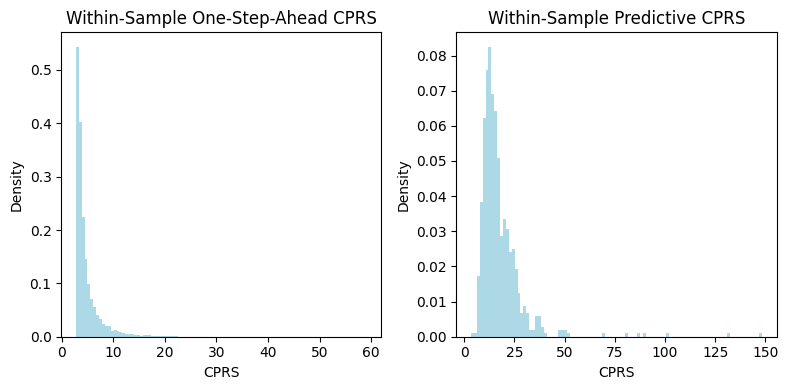

In [52]:
fig, axes = plt.subplots(1,2, figsize=(8, 4))

axes[0].hist(cprs_within_sample, 100, density=True, 
             color="lightblue")
axes[0].set_xlabel("CPRS")
axes[0].set_ylabel("Density")
axes[0].set_title("Within-Sample One-Step-Ahead CPRS")

axes[1].hist(cprs_outof_sample, 100, density=True, 
             color="lightblue");
axes[1].set_xlabel("CPRS")
axes[1].set_ylabel("Density")
axes[1].set_title("Within-Sample Predictive CPRS")

plt.tight_layout()

# Blog plots

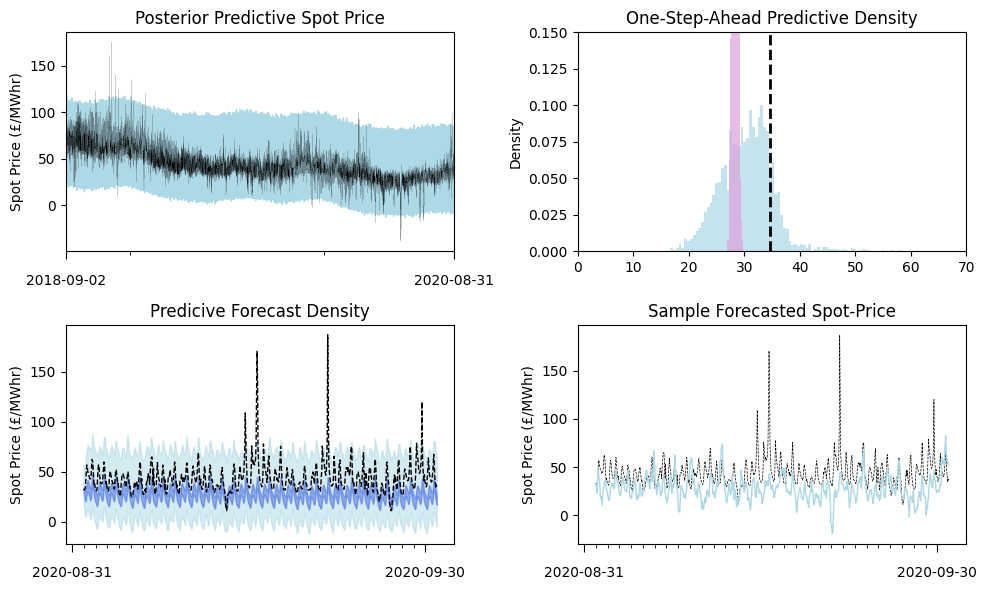

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=False)

axes[0,0].fill_between(training_data.index, 
                post_pred_qnts[0], 
                post_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[0,0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[0,0].set_title("Posterior Predictive Spot Price")
axes[0,0].set_ylabel("Spot Price (£/MWhr)")

# Show only the first and final day labels at their 00:00 observations
first_tick = training_data.index[0]
last_tick = training_data.index[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='YE'
)

axes[0,0].set_xlim(first_tick, last_tick)
axes[0,0].set_xticks([first_day_tick, last_day_tick])
axes[0,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[0,0].set_xticks(intermediate_day_ticks, minor=True)
axes[0,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[0,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[0,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


axes[0,1].hist(one_step_pred[:,-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="p()");
axes[0,1].hist(one_step_expected[:,-1], 100, density=True, 
             color='plum', alpha=0.7, label="E()");
axes[0,1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="y")
axes[0,1].set_ylim([0, 0.15])
axes[0,1].set_xlim([0,70])
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("One-Step-Ahead Predictive Density")

axes[1,0].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[0], 
                pred_sample_fore_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1,0].fill_between(validation_X_data['time'], 
                pred_sample_fore_qnts[1], 
                pred_sample_fore_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1,0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1,0].set_title("Predicive Forecast Density")
axes[1,0].set_ylabel("Spot Price (£/MWhr)")

first_tick = validation_X_data['time'].iloc[0]
last_tick = validation_X_data['time'].iloc[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='D'
)

axes[1,0].set_xticks([first_day_tick, last_day_tick])
axes[1,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,0].set_xticks(intermediate_day_ticks, minor=True)
axes[1,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

axes[1,1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=0.5, linestyle='--', alpha=1.0, )
axes[1,1].plot(validation_X_data['time'], pred_sample_fore[0], 
             color='lightblue', linewidth=1.0, linestyle='-', alpha=1.0,)
axes[1,1].set_title("Sample Forecasted Spot-Price")
axes[1,1].set_ylabel("Spot Price (£/MWhr)")

axes[1,1].set_xticks([first_day_tick, last_day_tick])
axes[1,1].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,1].set_xticks(intermediate_day_ticks, minor=True)
axes[1,1].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,1].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,1].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


plt.tight_layout()
